### Necessary Imports

In [34]:
from astropy.table import Table
from matplotlib import colors
from matplotlib import pyplot as plt
import numpy as np
import os
import pandas as pd
import pathlib

#### Now we'll use the stored rcparams.txt file to format our figure

In [35]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

### Now let's read in all our good CNN predicted periods

In [36]:
reportable = pd.read_csv('reportable.csv', index_col='Unnamed: 0').rename(columns={'edr3_source_id':'EDR3'})
reportable['bp-rp'] = reportable['phot_bp_mean_mag']-reportable['phot_rp_mean_mag']
reportable['abs_g_mag'] = reportable['phot_g_mean_mag'] - 5*np.log10(1000/reportable['parallax']) + 5

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


### Let's make a function to remake the scatter plots for each individual survey

In [37]:
def comparisons_plotter_6x(tables, parameter='bp-rp', save=False):
    """
    The comparison plotter function takes in all the compared predictions and plots them as a 3x2 image to demonstrate
    overlapping prediction accuracy and to color the objects by their absolute magnitude

    :param tables: list object of pd.DataFrame objects that contains inferred periods from both surveys
    :param parameter: string object of the DataFrame column to color the scatter plots and normalize the colorbar by 
    :param save: bool object to denote whether or not to save the figure.
    """   
    min = 0.001
    max = 0.001
    for table in tables:
        if(float(np.nanmin(table[parameter])) <= min):
            min = np.nanmin(table[parameter])
        if(float(np.nanmax(table[parameter])) >= max):
            max = np.nanmax(table[parameter])
    if(parameter=='teff_xgboost'):
        normi = colors.Normalize(3000, 6000)
    else:
        normi = colors.Normalize(min, max)

    fig, axes = plt.subplots(2, 3, figsize=(34, 20))
    
    for index, (axs, table) in enumerate(zip(axes.flat, tables)):
        
        axs.set_ylim(0, 30)
        
        axs.text(1.5, 28.3, f"{len(table)} total overlap", fontweight='bold', rasterized=True)
        period = "period"
        if(index==0):
            prot = "Prot"
            suptitle1 = 'Lu et al. (ZTF)'
        elif(index==1):
            prot = "Per"
            suptitle1 = 'Claytor & Tayar (Kbonus)'
        elif(index==2):
            prot = "Prot"
            suptitle1 = 'Santos et al. (Kepler)'
        elif(index==3):
            prot = "Prot"
            suptitle1 = 'Holcomb et al. (TESS)'
        elif(index==4):
            prot = "prot"
            suptitle1 = 'Claytor et al. (TESS)'
        elif(index==5):
            prot = "Adjusted period"
            suptitle1 = 'Colman et al. (TESS)'
        notlunaralias = table[(table['period']>28) | (table['period']<22)]
        lunaralias = table[(table['period']<=28) & (table['period']>=22)]

        pl0 = axs.scatter(prot, period , data=notlunaralias, c=parameter, norm=normi, cmap='hot_r', marker="*", s=150, rasterized=True)
        axs.scatter(prot, period , data=lunaralias, c='white', edgecolors= "k", marker='o', s=100, rasterized=True)
        
        x_lines = np.linspace(0, 30, 50)
        y_oneone = np.linspace(0, 30, 50)
        y_90_up = np.linspace(0, 30*.9, 50)
        x_90_bot = np.linspace(0, 30*.9, 50)
        y_double = np.linspace(0, 60, 50)
        y_half = np.linspace(0, 15, 50)

        #1:1 line
        axs.plot(x_lines, y_oneone, "r--", alpha=0.7)

        #90th percentile lines
        axs.plot(x_90_bot, y_oneone, "b:", alpha=0.7)
        axs.plot(x_lines, y_90_up, "b:", alpha=0.7)

        #2:1 and 1:2 aliases
        axs.plot(x_lines, y_double, "r:", alpha=0.7)
        axs.plot(x_lines, y_half, "r:", alpha=0.7)
        
        #Shaded 25% fractional error
        x_fill = [0, 37.5, 30, 0]
        y_fill = [0, 30, 37.5, 0]
        axs.fill(x_fill, y_fill, label=r'25% fractional error', color="#838383", alpha=0.35)

        axs.set(xlim=(0, 30), ylim=(0, 30))
        axs.set_title(suptitle1, weight='bold', rasterized=True)
    
    axes[0, 0].set_xlabel('(a)', weight='bold')
    axes[0, 1].set_xlabel('(b)', weight='bold')
    axes[0, 2].set_xlabel('(c)',  weight='bold')
    axes[1, 0].set_xlabel('(d)',  weight='bold')
    axes[1, 1].set_xlabel('(e)',  weight='bold')
    axes[1, 2].set_xlabel('(f)',  weight='bold')

    cbar = fig.colorbar(pl0, cmap='Spectral_r', ax=axes,  orientation='vertical', fraction=0.15)
    if(parameter=='bp-rp'):
        cbar.set_label(label = r'Gaia $B_p - R_p$ [dex]', weight='bold')
    if(parameter=='mh_xgboost'):
        cbar.set_label(label = r'XGBoost [M/H] [dex]', weight='bold')
    if(parameter=='teff_xgboost'):
        cbar.set_label(label = r'XGBoost T$ _{eff}$ [K]', weight='bold')
    if(parameter=='logg_xgboost'):
        cbar.set_label(label = r'XGBoost log(g) [dex]', weight='bold')
    if(parameter=='frac_err'):
        cbar.set_label(label = r'Fractional Error', weight='bold')
    if(parameter=='radius_val'):
        cbar.set_label(label = r'Gaia Bolometric Radius ($M_{\odot}$)', weight='bold')
    if(parameter=='lum_val'):
        cbar.set_label(label = r'Gaia Bolometric Luminosity ($L_{\odot}$)', weight='bold')
    fig.supxlabel('P$\\bf _{rot}$ (their work)', weight='bold', y=0.03, size=40)
    fig.supylabel('P$\\bf _{rot}$  (this work)', weight='bold', x=0.09, size=40)
    if(save==True):
        plt.savefig("color_compscat.pdf", dpi=300, bbox_inches='tight')

## Now we go catalog by catalog to make these files

### Note: Catalogs from Holcomb et al. (2022) and Colman et al. (2024) are both TESS, but these catalogs are currently not public. Please contact the appropriate PI to get these files

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


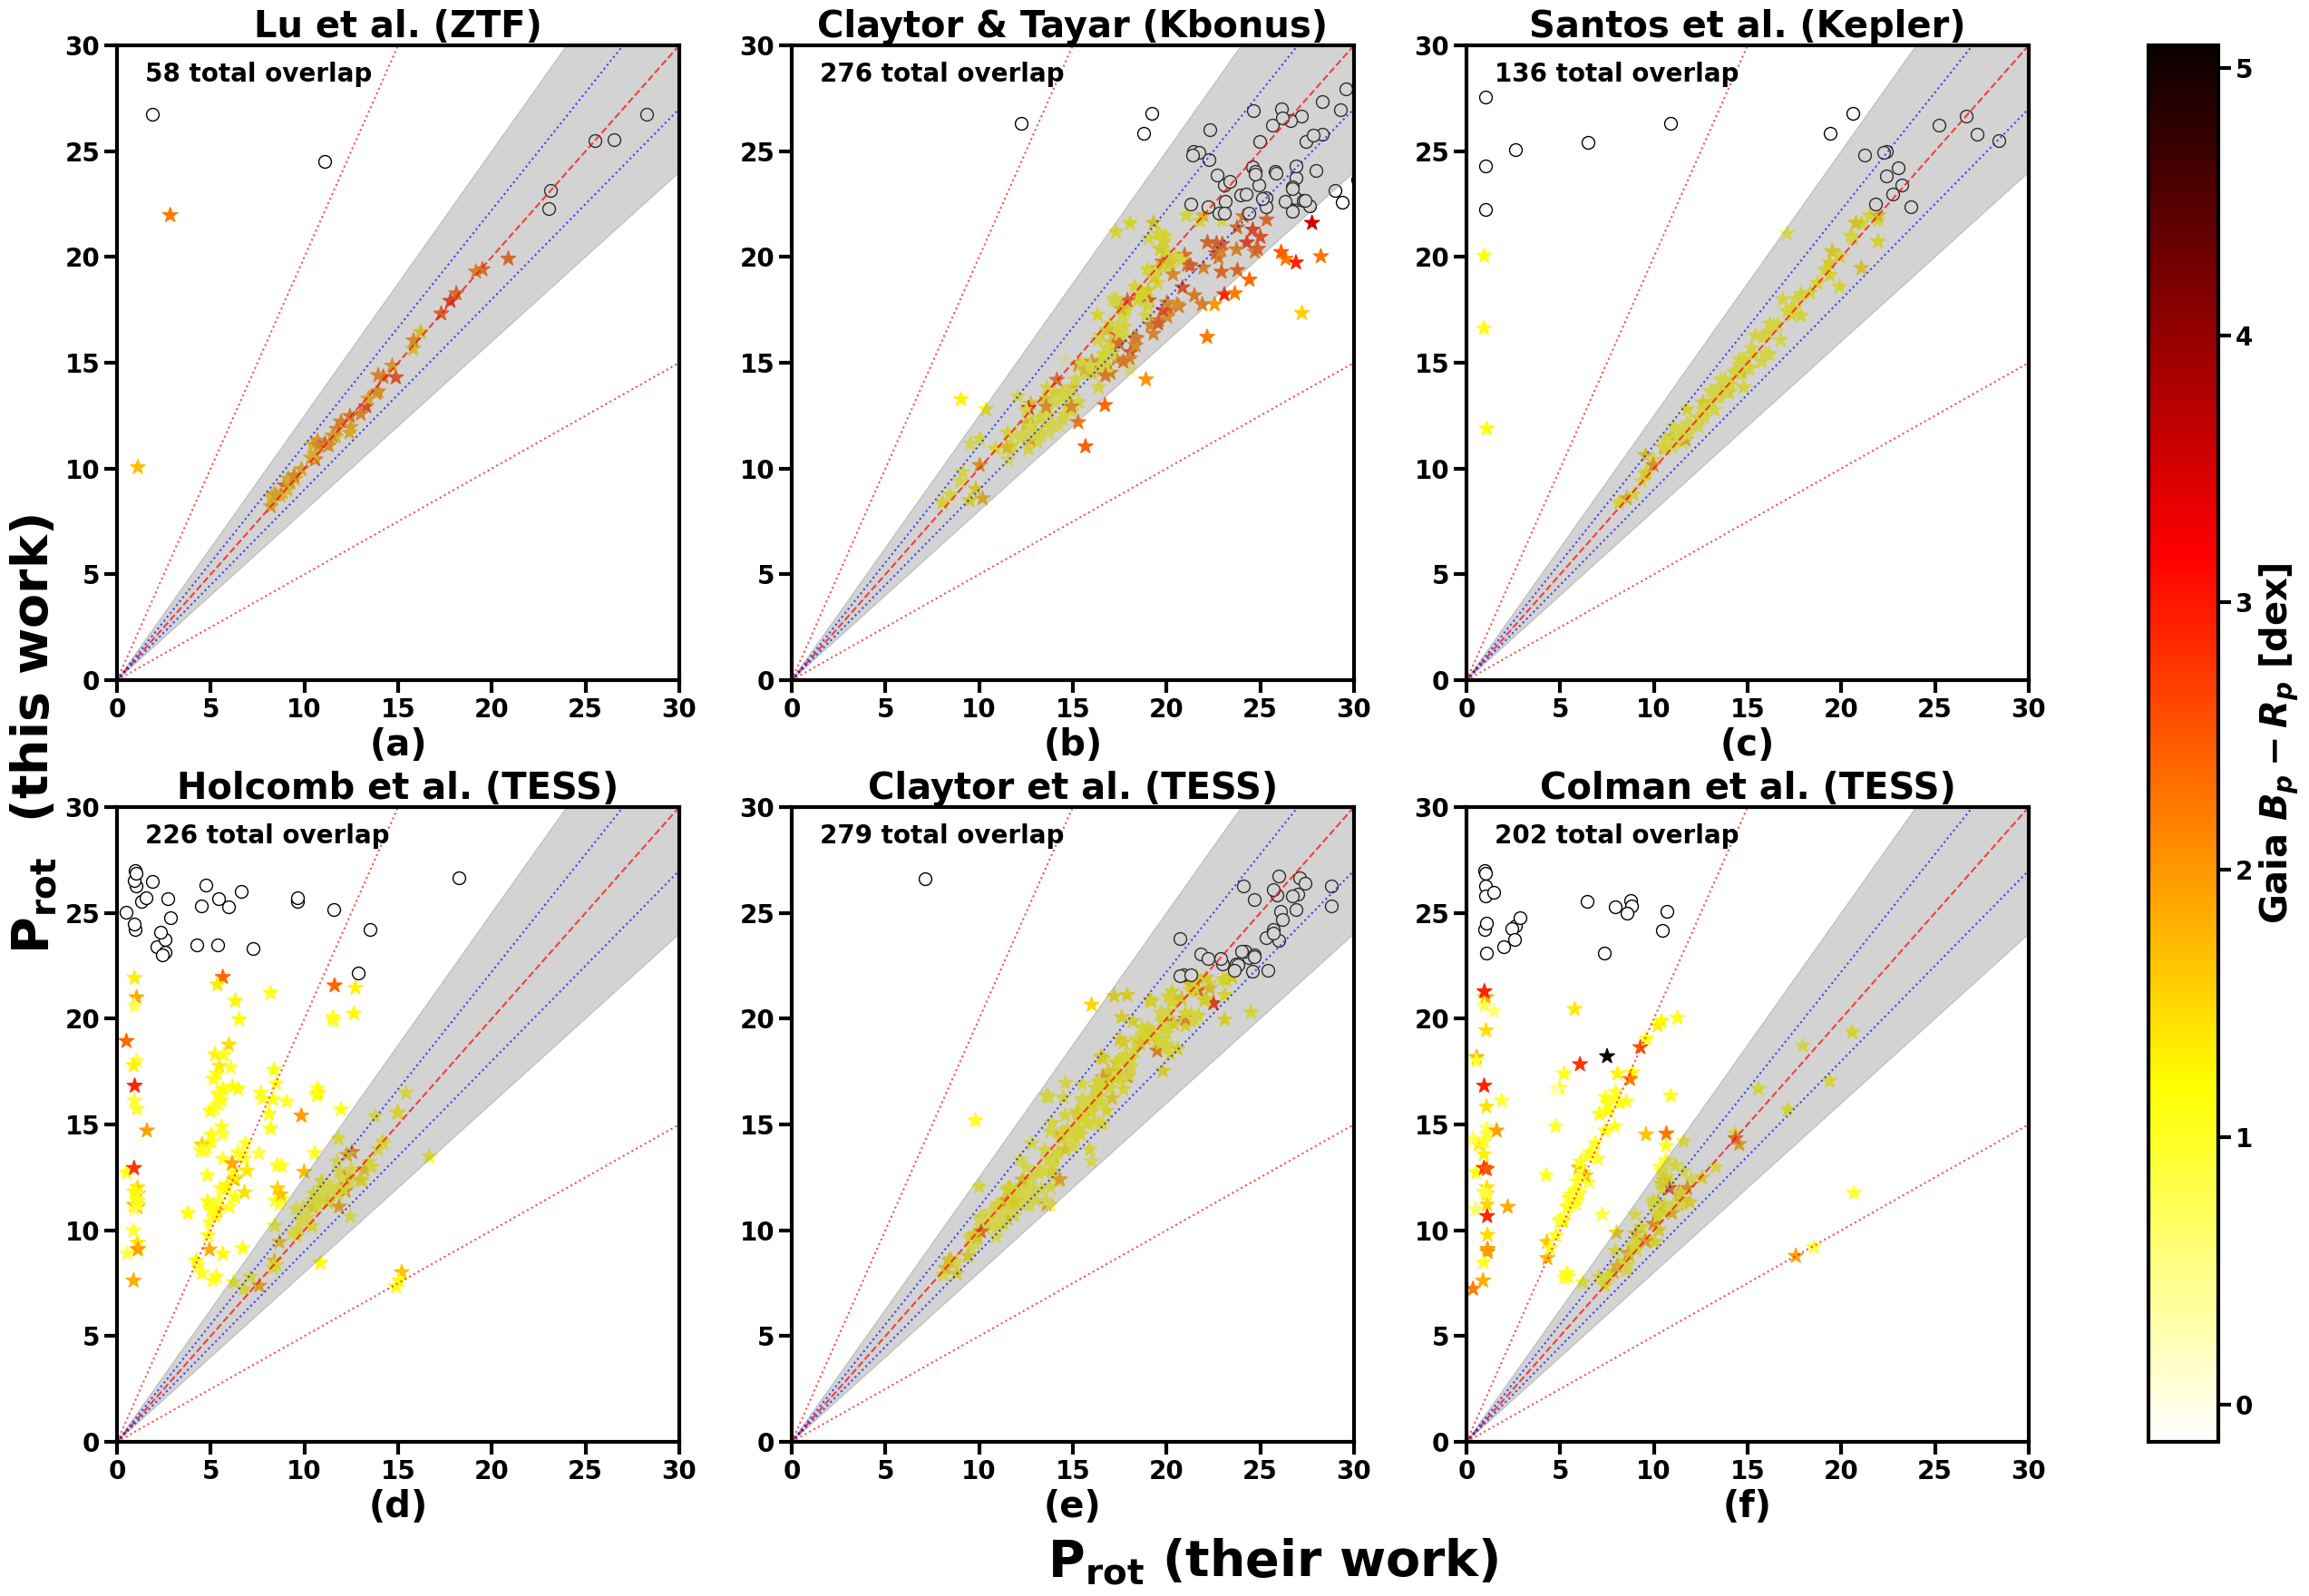

In [39]:
ztf = Table.read('files/crossmatch/luztf.txt', format="ascii.cds").to_pandas()
ztf0 = pd.merge(reportable, ztf, on='EDR3', how='inner').drop_duplicates(subset=['asas_sn_id'])

kbonuszc = Table.read('files/crossmatch/claytorkbonus.txt', format="ascii.cds").to_pandas()#.rename(columns={'TIC':'tic_id'})
kbonuszc['dr3_source_id'] = kbonuszc['GaiaDR3'].map(lambda x: x.lstrip('Gaia DR3'))
kbonuszc = kbonuszc.drop('GaiaDR3', axis=1)
kbonuszc['abs_g'] = (kbonuszc['phot_g_mean_mag']+5-(5*np.log10(1000/kbonuszc['plx']))).replace([np.inf, -np.inf], np.nan)
kbonuszc['dr3_source_id'] = kbonuszc['dr3_source_id'].fillna(0).astype(np.int64)
kbonuszc0 = pd.merge(reportable, kbonuszc, on='dr3_source_id', how='inner').drop_duplicates(subset=['dr3_source_id'])

santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()
santostot = pd.concat([santos1, santos2])
santos0 = pd.merge(reportable, santostot, on='KIC', how='inner').drop_duplicates(subset=['asas_sn_id'])

holcombcat = pd.read_csv('spinspotter_by_star.csv').rename(columns={'TICID':'tic_id'})
holcombperiods = holcombcat[holcombcat['rotation_accepted']==True]
holcombcat0 = pd.merge(reportable, holcombperiods, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])

tesszc = Table.read('files/crossmatch/claytortess.txt', format="ascii.cds").to_pandas().rename(columns={'TIC':'tic_id'})
tesszc0 = pd.merge(reportable, tesszc, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])

colmancat = pd.read_csv('colmantess.csv').drop(labels=['Unnamed: 0'], axis=1).rename(columns={'TIC':'tic_id'})
colmancat0 = pd.merge(reportable, colmancat, on='tic_id', how='inner').drop_duplicates(subset=['tic_id'])


ztf0['bp-rp'] = ztf0['phot_bp_mean_mag']-ztf0['phot_rp_mean_mag']
kbonuszc0['bp-rp'] = kbonuszc0['phot_bp_mean_mag_x']-kbonuszc0['phot_rp_mean_mag_x']
santos0['bp-rp'] = santos0['phot_bp_mean_mag']-santos0['phot_rp_mean_mag']
holcombcat0['bp-rp'] = holcombcat0['phot_bp_mean_mag']-holcombcat0['phot_rp_mean_mag']
tesszc0['bp-rp'] = tesszc0['phot_bp_mean_mag']-tesszc0['phot_rp_mean_mag']
colmancat0['bp-rp'] = colmancat0['phot_bp_mean_mag']-colmancat0['phot_rp_mean_mag']

catalogs = [ztf0, kbonuszc0, santos0, holcombcat0, tesszc0, colmancat0]

comparisons_plotter_6x(catalogs, parameter = 'bp-rp', save=True)